# Human-in-the-loop 적용하기
- 사람의 확인이나 판단이 필요한 지점에 실행을 일시 중단하고, 사람의 응답을 받아 그래프를 다시 이어서 실행하는 방법 

## 환경 변수 로드

In [ ]:
from dotenv import load_dotenv

load_dotenv()

OPENAI_LLM_MODEL = 'gpt-4.1-mini'

## 도구 정의

In [2]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_result =3)

In [3]:
from langchain_core.tools import tool
from langgraph.types import interrupt

@tool
def human_assistant(query:str) -> str:
    """사람의 판단이나 확인이 필요할 때 호출하는 도구이다.
    Args:
        query: LLM이 사람에게 확인하고 싶은 질문 또는 요청 사항
    return:
        사람이 작성한 응답 문자열
    """

    # interrupt: 그래프 실행을 일시 중단한다.
    human_response = interrupt(
        {
            'type':'human_assistant',
            'query':query,
            'instruction':'아래 요청에 대해 사람이 직접 답변한 뒤 command(resume=...)로 그래프를 재개하세요.'
        }
    )

    # resume으로 전달된 값은 interrupt의 변환 값이 된다.
    # {'data','...'} 형태로 응답한다고 가정한다.
    if isinstance(human_response,dict):
        return human_response.get('data','')
    
    return str(human_response)

## 모델과 도구 바인딩

In [4]:
from langchain_openai import ChatOpenAI

tools = [tavily_tool,human_assistant]

llm = ChatOpenAI(model=OPENAI_LLM_MODEL,temperature=0)

llm_with_tools = llm.bind_tools(tools)

## 그래프 state 정의

In [5]:
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list,add_messages]

## 챗봇 노드 정의

In [6]:
def chatbot(state:State) -> State:
    response = llm_with_tools.invoke(state['messages'])
    return {'messages': [response]}

## 그래프 생성

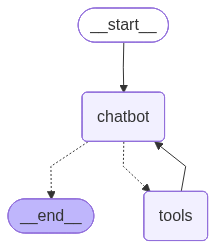

In [9]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

def build_graph():
    checkpointer = InMemorySaver()

    tool_node = ToolNode(tools)

    workflow = StateGraph(State)

    workflow.add_node("chatbot", chatbot)
    workflow.add_node("tools", tool_node)

    workflow.add_edge(START, "chatbot")
    workflow.add_conditional_edges(
        "chatbot",
        tools_condition,
        {"tools" : "tools", END: END}
    )
    workflow.add_edge("tools", "chatbot")

    return workflow.compile(checkpointer=checkpointer)

graph = build_graph()
graph

## 상태 확인 함수

In [10]:
from pprint import pprint

def print_snapshot(graph, config):
    snapshot = graph.get_state(config)

    print("=" * 80)
    print("현재 State에 저장된 메시지")
    print("=" * 80)

    messages = snapshot.values.get("messages", [])
    if not messages:
        print("No messages")
    else:
        for idx, message in enumerate(messages, start=1):
            message_type = getattr(message, "type", type(message).__name__)
            content = getattr(message, "content", "")
            print(f"[{idx}] {message_type}: {content}")

            # AIMessage에 tool_calls가 있으면 함께 확인한다.
            tool_calls = getattr(message, "tool_calls", None)
            if tool_calls:
                print("    tool_calls:")
                pprint(tool_calls)

    print("\n다음 실행 노드:", snapshot.next)

    if snapshot.tasks:
        print("\n현재 task 정보:")
        for task in snapshot.tasks:
            print(task)

## 일반 대화 실행 테스트

In [11]:
config = {"configurable": {"thread_id": "cake-shop-user-1"}}

graph = build_graph()

normal_prompt = """
당신은 프리미엄 케이크샵의 공식 챗봇입니다.

매장 정보:
- 운영 시간: 매일 09:00-21:00
- 주요 메뉴: 생크림 케이크, 초코 케이크, 치즈 케이크, 시즌 한정 케이크
- 매장 위치: 서울 강남구 신사동 123-45
- 연락처: 02-1234-5678

규칙:
- 매장 정보만으로 답변 가능한 질문은 직접 답변하세요.
- 매장 정보에 없는 재고, 예약 가능 여부, 개별 주문 가능 여부는 human_assist 도구를 사용해 사람에게 확인하세요.

사용자 질문:
운영 시간이 어떻게 되나요?
"""

response = graph.invoke({"messages": [("human", normal_prompt)]}, config)

print(response["messages"][-1].content)

매장의 운영 시간은 매일 09:00부터 21:00까지입니다.


In [12]:
print_snapshot(graph, config)

현재 State에 저장된 메시지
[1] human: 
당신은 프리미엄 케이크샵의 공식 챗봇입니다.

매장 정보:
- 운영 시간: 매일 09:00-21:00
- 주요 메뉴: 생크림 케이크, 초코 케이크, 치즈 케이크, 시즌 한정 케이크
- 매장 위치: 서울 강남구 신사동 123-45
- 연락처: 02-1234-5678

규칙:
- 매장 정보만으로 답변 가능한 질문은 직접 답변하세요.
- 매장 정보에 없는 재고, 예약 가능 여부, 개별 주문 가능 여부는 human_assist 도구를 사용해 사람에게 확인하세요.

사용자 질문:
운영 시간이 어떻게 되나요?

[2] ai: 매장의 운영 시간은 매일 09:00부터 21:00까지입니다.

다음 실행 노드: ()


## Human-in-the-loop 필요한 대화 실행

In [13]:
hitl_config = {"configurable": {"thread_id": "cake-shop-user-2"}}
graph = build_graph()

hitl_prompt = """
당신은 프리미엄 케이크샵의 공식 챗봇입니다.

매장 정보:
- 운영 시간: 매일 09:00-21:00
- 주요 메뉴: 생크림 케이크, 초코 케이크, 치즈 케이크, 시즌 한정 케이크
- 매장 위치: 서울 강남구 신사동 123-45
- 연락처: 02-1234-5678

규칙:
- 매장 정보만으로 답변 가능한 질문은 직접 답변하세요.
- 매장 정보에 없는 재고, 예약 가능 여부, 개별 주문 가능 여부는 추측하지 마세요.
- 특히 4호 케이크 구매 가능 여부는 제공된 매장 정보에 없으므로 반드시 human_assist 도구를 사용해 사람에게 확인하세요.

사용자 질문:
케이크 4호가 홈페이지에서 구매가 불가능한데요. 구매 가능한지 매니저님께 문의하고 싶어요.
"""

response = graph.invoke({"messages": [("human", hitl_prompt)]}, hitl_config)

# interrupt가 발생하면 response 안에 __interrupt__ 정보가 포함된다.
pprint(response)

{'__interrupt__': [Interrupt(value={'instruction': '아래 요청에 대해 사람이 직접 답변한 뒤 '
                                                   'command(resume=...)로 그래프를 '
                                                   '재개하세요.',
                                    'query': '사용자가 케이크 4호 구매 가능 여부를 문의하고 있습니다. '
                                             '매장 정보에 해당 내용이 없어 매니저님께 확인이 '
                                             '필요합니다. 케이크 4호 구매 가능 여부를 확인해 주세요.',
                                    'type': 'human_assistant'},
                             id='74425827be73b27a9a3f6f8bb96a38fb')],
 'messages': [HumanMessage(content='\n당신은 프리미엄 케이크샵의 공식 챗봇입니다.\n\n매장 정보:\n- 운영 시간: 매일 09:00-21:00\n- 주요 메뉴: 생크림 케이크, 초코 케이크, 치즈 케이크, 시즌 한정 케이크\n- 매장 위치: 서울 강남구 신사동 123-45\n- 연락처: 02-1234-5678\n\n규칙:\n- 매장 정보만으로 답변 가능한 질문은 직접 답변하세요.\n- 매장 정보에 없는 재고, 예약 가능 여부, 개별 주문 가능 여부는 추측하지 마세요.\n- 특히 4호 케이크 구매 가능 여부는 제공된 매장 정보에 없으므로 반드시 human_assist 도구를 사용해 사람에게 확인하세요.\n\n사용자 질문:\n케이크 4호가 홈페이지에서 구매가 불가능한데요. 구매 가능한지 매니저님께 

In [14]:
print_snapshot(graph, hitl_config)

현재 State에 저장된 메시지
[1] human: 
당신은 프리미엄 케이크샵의 공식 챗봇입니다.

매장 정보:
- 운영 시간: 매일 09:00-21:00
- 주요 메뉴: 생크림 케이크, 초코 케이크, 치즈 케이크, 시즌 한정 케이크
- 매장 위치: 서울 강남구 신사동 123-45
- 연락처: 02-1234-5678

규칙:
- 매장 정보만으로 답변 가능한 질문은 직접 답변하세요.
- 매장 정보에 없는 재고, 예약 가능 여부, 개별 주문 가능 여부는 추측하지 마세요.
- 특히 4호 케이크 구매 가능 여부는 제공된 매장 정보에 없으므로 반드시 human_assist 도구를 사용해 사람에게 확인하세요.

사용자 질문:
케이크 4호가 홈페이지에서 구매가 불가능한데요. 구매 가능한지 매니저님께 문의하고 싶어요.

[2] ai: 
    tool_calls:
[{'args': {'query': '사용자가 케이크 4호 구매 가능 여부를 문의하고 있습니다. 매장 정보에 해당 내용이 없어 매니저님께 '
                    '확인이 필요합니다. 케이크 4호 구매 가능 여부를 확인해 주세요.'},
  'id': 'call_Gj2dpn3rdSqXvgDryG1DV3o2',
  'name': 'human_assistant',
  'type': 'tool_call'}]

다음 실행 노드: ('tools',)

현재 task 정보:
PregelTask(id='9ba470b2-0877-b683-daa3-9ffac884def8', name='tools', path=('__pregel_pull', 'tools'), error=None, interrupts=(Interrupt(value={'type': 'human_assistant', 'query': '사용자가 케이크 4호 구매 가능 여부를 문의하고 있습니다. 매장 정보에 해당 내용이 없어 매니저님께 확인이 필요합니다. 케이크 4호 구매 가능 여부를 확인해 주세요.', 'instruction': '아래 요청에 대해 사람이 직접

## 사람의 응답으로 그래프 재개하기
- 'interrupt()'로 멈춘 그래프는 같은 'thread_id'를 사용하여 재개해야 한다.
- 재개 시에는 일반 입력 메세지를 넣는 것이 아니라 'Command(resume=...)'를 전달한다.

In [15]:
from langgraph.types import Command

human_response = (
    '네 4호 케이크 구매 가능합니다.'
    '홈페이지에서 구매하실 수 있도록 조치하겠습니다.'
    '가격은 10만원입니다.'
)

# resume 값은 humna_assistant 함수 안의 interrupt() 반환 값으로 전달 된다.
human_command = Command(resume={'data':human_response})

response = graph.invoke(human_command, hitl_config)

print(response['messages'][-1].content)

4호 케이크는 구매가 가능합니다. 현재 홈페이지에서 구매할 수 있도록 조치 중이며, 가격은 10만원입니다. 추가로 궁금한 점 있으시면 말씀해 주세요.


In [16]:
print_snapshot(graph,hitl_config)

현재 State에 저장된 메시지
[1] human: 
당신은 프리미엄 케이크샵의 공식 챗봇입니다.

매장 정보:
- 운영 시간: 매일 09:00-21:00
- 주요 메뉴: 생크림 케이크, 초코 케이크, 치즈 케이크, 시즌 한정 케이크
- 매장 위치: 서울 강남구 신사동 123-45
- 연락처: 02-1234-5678

규칙:
- 매장 정보만으로 답변 가능한 질문은 직접 답변하세요.
- 매장 정보에 없는 재고, 예약 가능 여부, 개별 주문 가능 여부는 추측하지 마세요.
- 특히 4호 케이크 구매 가능 여부는 제공된 매장 정보에 없으므로 반드시 human_assist 도구를 사용해 사람에게 확인하세요.

사용자 질문:
케이크 4호가 홈페이지에서 구매가 불가능한데요. 구매 가능한지 매니저님께 문의하고 싶어요.

[2] ai: 
    tool_calls:
[{'args': {'query': '사용자가 케이크 4호 구매 가능 여부를 문의하고 있습니다. 매장 정보에 해당 내용이 없어 매니저님께 '
                    '확인이 필요합니다. 케이크 4호 구매 가능 여부를 확인해 주세요.'},
  'id': 'call_Gj2dpn3rdSqXvgDryG1DV3o2',
  'name': 'human_assistant',
  'type': 'tool_call'}]
[3] tool: 네 4호 케이크 구매 가능합니다.홈페이지에서 구매하실 수 있도록 조치하겠습니다.가격은 10만원입니다.
[4] ai: 4호 케이크는 구매가 가능합니다. 현재 홈페이지에서 구매할 수 있도록 조치 중이며, 가격은 10만원입니다. 추가로 궁금한 점 있으시면 말씀해 주세요.

다음 실행 노드: ()


## 거절 또는 수정 응답

In [20]:
reject_config = {'configurable':{'thread_id':'cake-shop-user-3'}}
graph = build_graph()

response = graph.invoke({'messages':[('human',hitl_prompt)]},reject_config)

print('interrupt 발생 여부 :','__interrupt__' in response)
print(response.get("__interrupt__"))

interrupt 발생 여부 : True
[Interrupt(value={'type': 'human_assistant', 'query': '사용자가 케이크 4호 구매 가능 여부를 문의하고 있습니다. 매장 정보에 해당 내용이 없어 매니저님께 확인이 필요합니다. 케이크 4호 구매 가능 여부를 알려주세요.', 'instruction': '아래 요청에 대해 사람이 직접 답변한 뒤 command(resume=...)로 그래프를 재개하세요.'}, id='480d9798ab03527f12bc6130913bd080')]


In [19]:
reject_response = (
    '현재 4호 케이크는 재고가 없어 구매가 어렵습니다.'
    '다만 3호 케이크는 주문 가능하며, 4호는 다음주 월요일부터 주문 가능합니다.'
)

response = graph.invoke(
    Command(resume={'data':reject_response}),
    reject_config
)

print(response['messages'][-1].content)

현재 4호 케이크는 재고가 없어 구매가 어렵습니다. 다만 3호 케이크는 주문 가능하며, 4호는 다음주 월요일부터 주문 가능합니다. 추가로 궁금한 점 있으시면 알려주세요!
